# Superstore Sales Analysis

## Objective
Analyse 9,994 orders from a US retail store (2014–2017) to find
which regions, categories, and discounting behaviours drive
or destroy profitability.

## Dataset
Superstore Sales Dataset — sourced from Kaggle
Rows: 9,994 | Columns: 21
Key columns: Sales, Profit, Discount, Region, Category, Sub-Category


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [16]:
df = pd.read_csv('Superstore.csv' , encoding='latin1')

In [17]:
df


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


1.ALWAYS LOOK AT IT FIRST.


In [18]:
print(df.shape) #Rows and Columns count

(9994, 21)


In [19]:
print(df.info()) # summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [20]:
df.head() #First five rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
df.columns.tolist() # All Column Names

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

2.EDA STEP-1

In [22]:

df.describe() #statistics for number columns

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [23]:
df.isnull().sum() # Count missing values in each columns

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [24]:
print(df['Category'].unique())

['Furniture' 'Office Supplies' 'Technology']


In [25]:
print(df['Region'].unique())

['South' 'West' 'Central' 'East']


In [26]:

print(df['Segment'].unique())

['Consumer' 'Corporate' 'Home Office']


3.CLEAN THE DATA

In [27]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed') #convert text into date

In [28]:
df['Year'] = df['Order Date'].dt.year   #create useful new columns
df['Month'] = df['Order Date'].dt.month
df['Month_name'] = df['Order Date'].dt.strftime('%b')
df['Profit Margin'] = (df['Profit']/df['Sales'])*100


In [29]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_name,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,11.25


In [30]:
# Check for duplicate rows
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

print("Data cleaned. Shape:", df.shape)


Duplicates: 0
Data cleaned. Shape: (9994, 25)


4. SALES BY REGION -**BAR CHART**

In [31]:
# GROUP BY REGION AND SUM OF THE SALES
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


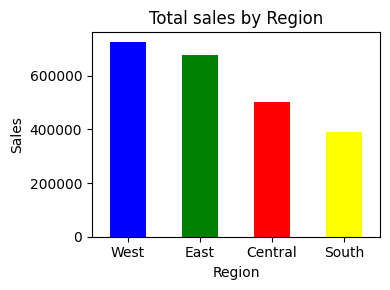

In [32]:
#plot it

plt.figure(figsize=(4,3))
region_sales.plot(kind='bar', color=['blue','green','red','yellow'])
plt.title('Total sales by Region')
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**West region** generates the highest sales ($725K), but the **South**
   has the best profit margin relative to sales.

5. PROFIT BY CATEGORY - MOST PROFITABLE!

In [33]:
# Sales vs Profit by category
cat_summary = df.groupby('Category')[['Sales','Profit']].sum()
print(cat_summary)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


<Figure size 200x200 with 0 Axes>

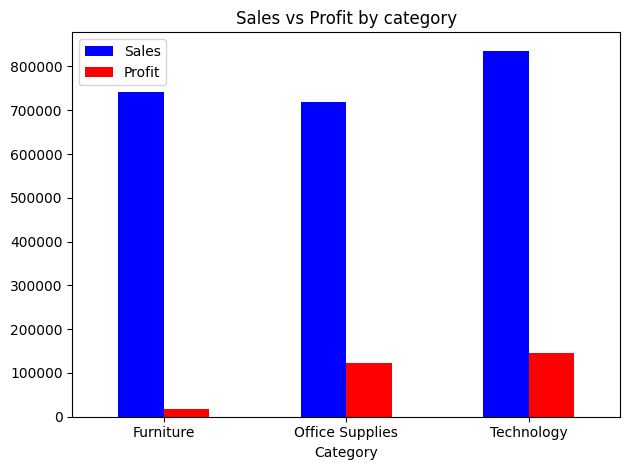

In [34]:
# Plot side by side bars

plt.figure(figsize=(2,2))
cat_summary.plot(kind='bar',color=['blue','red'])
plt.title('Sales vs Profit by category')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Furniture** has high sales ($742K) but near-zero profit —
   meaning the company is barely breaking even on furniture sales.

**Technology** is the most profitable category despite not having
   the highest sales volume.

In [35]:
# Profit margin by category

cat_margin = df.groupby('Category')['Profit Margin'].mean()
print("\n AVG Profit Margin %:")
print(cat_margin.round(2))


 AVG Profit Margin %:
Category
Furniture           3.88
Office Supplies    13.80
Technology         15.61
Name: Profit Margin, dtype: float64


6. MONTHLY SALES TREND - LINE CHART

In [36]:
# Monthly sales over all year
Monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
Monthly['Date'] = pd.to_datetime(Monthly[['Year','Month']].assign(day=1))
Monthly

,Year,Month,Sales,Date
0,2014,1,14236.8950,2014-01-01
1,2014,2,4519.8920,2014-02-01
2,2014,3,55691.0090,2014-03-01
3,2014,4,28295.3450,2014-04-01
4,2014,5,23648.2870,2014-05-01
5,2014,6,34595.1276,2014-06-01
6,2014,7,33946.3930,2014-07-01
7,2014,8,27909.4685,2014-08-01
8,2014,9,81777.3508,2014-09-01
9,2014,10,31453.3930,2014-10-01


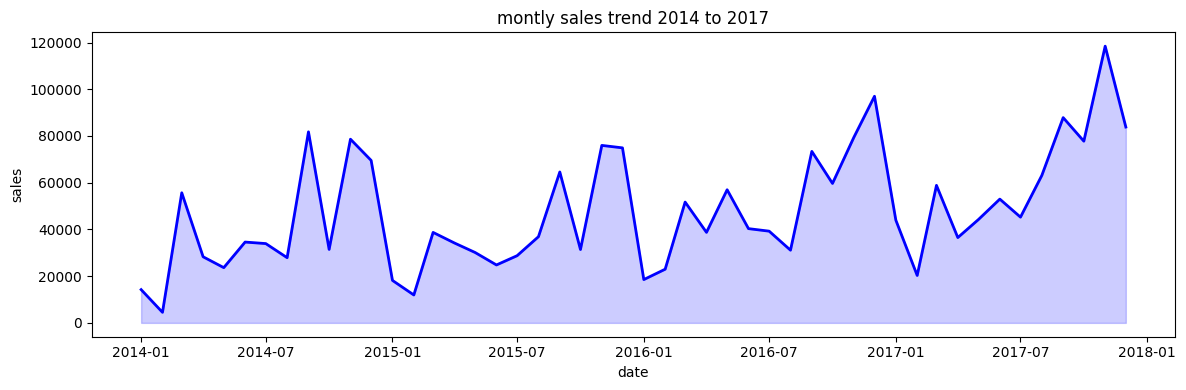

In [37]:
#line chart
plt.figure(figsize=(12,4))
plt.plot(Monthly['Date'],Monthly['Sales'],color='blue',linewidth=2)
plt.fill_between(Monthly['Date'],Monthly['Sales'],alpha=0.2, color='blue')
plt.title('montly sales trend 2014 to 2017')
plt.xlabel('date')
plt.ylabel('sales')
plt.tight_layout()
plt.show()

7. DISCOUNT VS PROFIT -are discount hurting us?

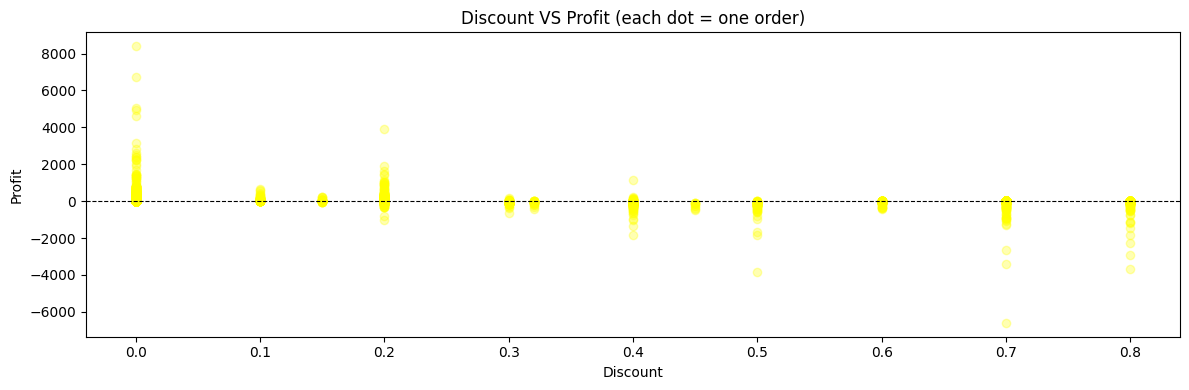

correlation :-0.22


In [38]:
# SCATTER PLOT - Does more discount = less profit?
plt.figure(figsize=(12,4))
plt.scatter(df['Discount'],df['Profit'], alpha=0.3, color='yellow')
plt.axhline(y=0,color='black', linewidth=0.8, linestyle='--')
plt.title('Discount VS Profit (each dot = one order)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

#Correlation Number
corr = df['Discount'].corr(df['Profit'])
print(f"correlation :{corr:.2f}")

**Discounts above 20%** strongly correlate with losses (correlation: -0.22).
   Orders with 40%+ discounts almost always result in negative profit.


8. TOP 10 SUB CATEGORYS BY PROFIT


In [39]:
print(df['Sub-Category'].unique())

['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [40]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


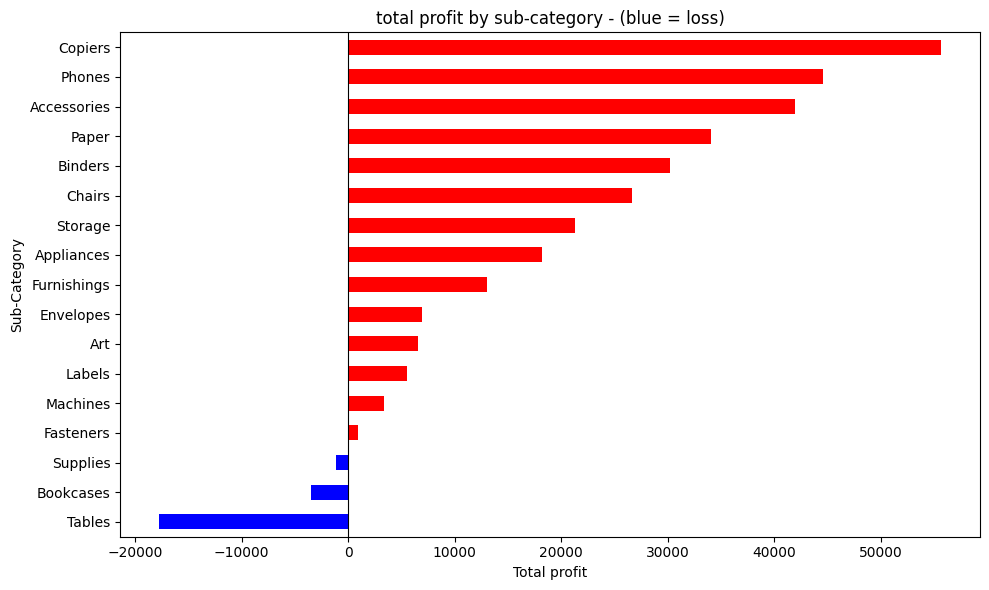

In [41]:
colors = ['blue' if x<0 else 'red' for x in subcat_profit]
plt.figure(figsize=(10,6))
subcat_profit.plot(kind='barh', color=colors)
plt.axvline(x=0,linewidth=0.8, color='black')
plt.title('total profit by sub-category - (blue = loss)')
plt.xlabel('Total profit')
plt.tight_layout()
plt.show()

**Tables** and **Bookcases** sub-categories consistently lose money
   and should be reviewed or discontinued.
   

9. HEATMAP - SALES BY REGION AND CATEGORY

Category    Furniture  Office Supplies  Technology
Region                                            
Central   163797.1638       167026.415  170416.312
East      208291.2040       205516.055  264973.981
South     117298.6840       125651.313  148771.908
West      252612.7435       220853.249  251991.832


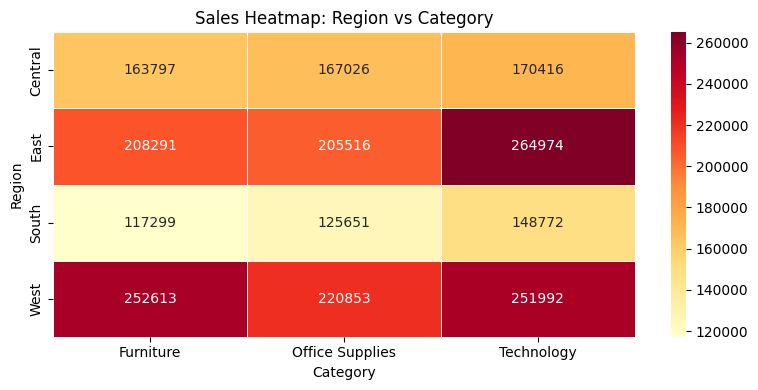

In [42]:
#PIVOT TABLE BEFORE HEATMAP

pivot = df.pivot_table(values='Sales', index='Region',columns='Category' ,aggfunc='sum' )
print(pivot)

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Sales Heatmap: Region vs Category')
plt.tight_layout()
plt.show()

## Key Findings & Business Recommendations

1. **West dominates sales** but profit margins vary — high revenue
   does not always mean high profit.

2. **Furniture is a loss risk** — high sales volume but only ~2.5%
   profit margin. Pricing strategy needs a review.

3. **Discounts above 20% destroy profit** — correlation of -0.22
   between discount and profit. Recommend capping discounts at 20%.

4. **Technology is the most profitable category** — highest margins
   despite moderate sales. More marketing investment here would help.

5. **Q4 seasonal spike every year** — November and December always
   see peak sales. Inventory and staffing should be planned around this.

## Recommendation
Focus on Technology expansion, fix Furniture pricing,
and enforce a 20% discount cap company-wide.